<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

원본 이미지


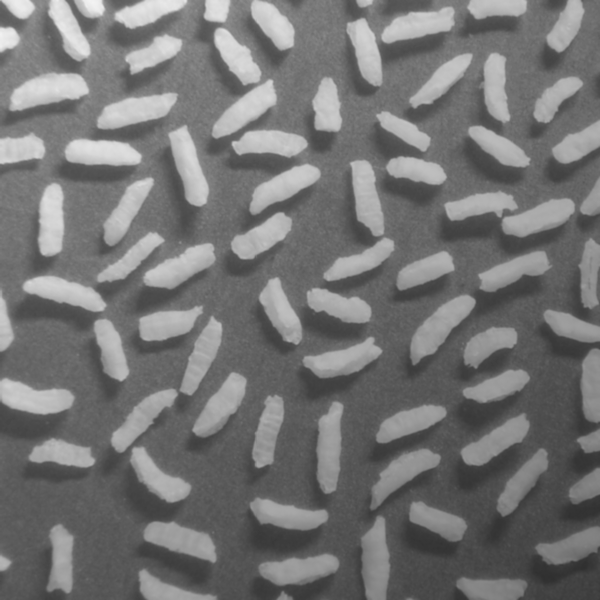

Otsu threshold = 134.0
Otsu 이진화 결과


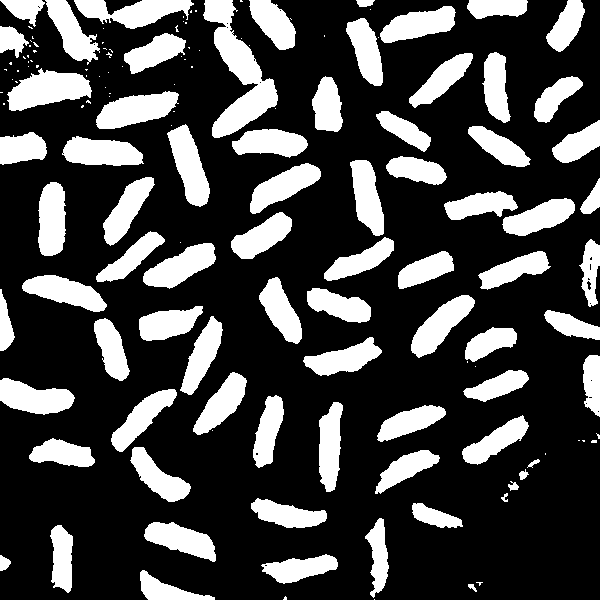

Top-hat 결과


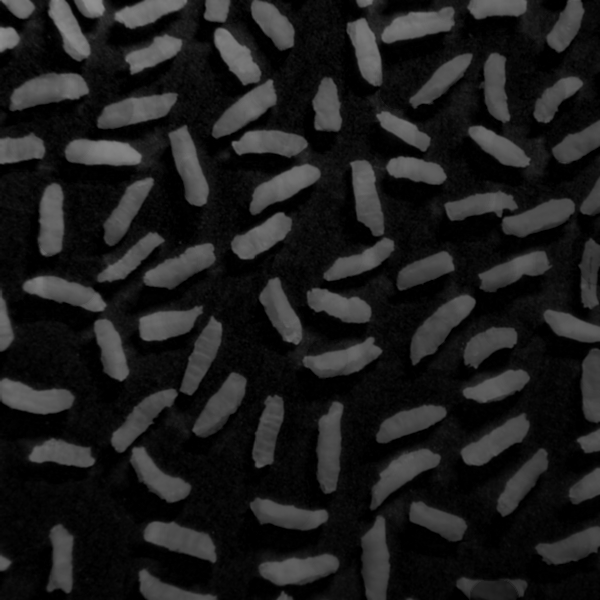

Top-hat + Otsu threshold = 44.0
Top-hat + Otsu 이진화 결과


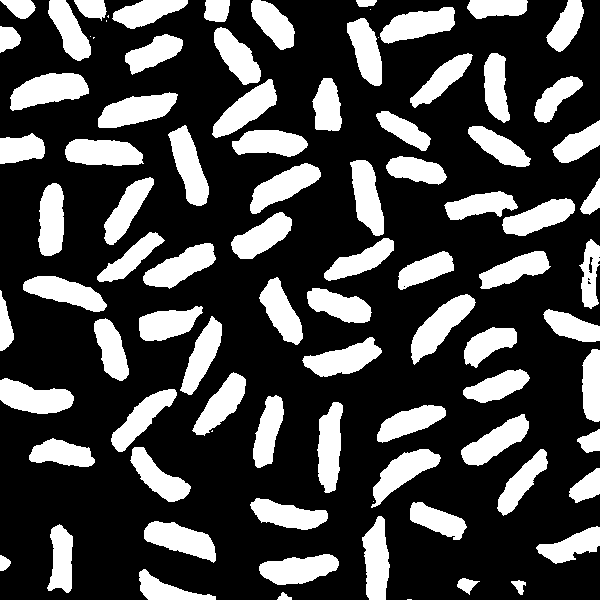

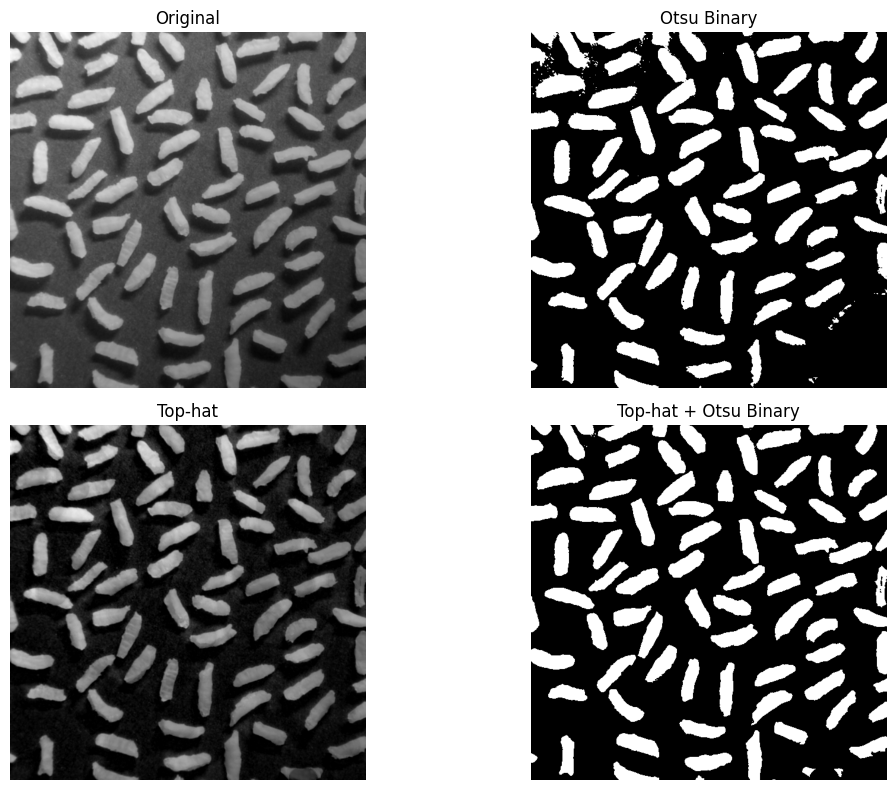

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

# -------------------------------
# 1) 이미지 업로드
# -------------------------------
img = cv2.imread('/content/Fig0940(a)(rice_image_with_intensity_gradient).tif', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("이미지를 불러오지 못했습니다.")

print("원본 이미지")
cv2_imshow(img)

# -------------------------------
# 2) Otsu 이진화
# -------------------------------
otsu_thresh, otsu_binary = cv2.threshold(
    img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold =", otsu_thresh)
print("Otsu 이진화 결과")
cv2_imshow(otsu_binary)

# -------------------------------
# 3) Top-hat 변환
# -------------------------------
# 구조요소 크기는 객체보다 너무 크지 않게 잡는 것이 중요
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))

tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

print("Top-hat 결과")
cv2_imshow(tophat)

# -------------------------------
# 4) Top-hat 결과를 다시 이진화
# 방법 1: Otsu 사용
# -------------------------------
tophat_otsu_thresh, tophat_otsu_binary = cv2.threshold(
    tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Top-hat + Otsu threshold =", tophat_otsu_thresh)
print("Top-hat + Otsu 이진화 결과")
cv2_imshow(tophat_otsu_binary)

# -------------------------------
# 5) 결과 비교 출력
# -------------------------------
titles = [
    'Original',
    'Otsu Binary',
    'Top-hat',
    'Top-hat + Otsu Binary'
]

images = [
    img,
    otsu_binary,
    tophat,
    tophat_otsu_binary
]

plt.figure(figsize=(12, 8))
for i in range(len(images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()